In [10]:
# ── CELL 1: Consolidated setup — paths, systems, index files, input files ──

import subprocess
from pathlib import Path

PROJECT_ROOT = Path.home() / "mmpbsa_project"
TRAJ_DIR = PROJECT_ROOT / "trajectories_clean"
TPR_DIR = PROJECT_ROOT / "tpr_files"
NDX_DIR = PROJECT_ROOT / "index_files"
LIGAND_PARAMS_DIR = PROJECT_ROOT / "ligand_params"
MMPBSA_INPUT_DIR = PROJECT_ROOT / "mmpbsa_inputs"
RESULTS_DIR = PROJECT_ROOT / "results"

for d in [NDX_DIR, MMPBSA_INPUT_DIR, RESULTS_DIR]:
    d.mkdir(exist_ok=True)

systems = {
    "CNP0286261_0": TPR_DIR / "CNP0286261_0_md.tpr",
    "CNP0275186_1": TPR_DIR / "CNP0275186_1_md.tpr",
    "CNP0539885_2": TPR_DIR / "CNP0539885_2_md.tpr",
    "pyrimethamine": TPR_DIR / "pyrimethamine_md.tpr",
}

frame_info = {
    "CNP0286261_0": {"endframe": 10010},
    "CNP0275186_1": {"endframe": 10010},
    "CNP0539885_2": {"endframe": 10010},
    "pyrimethamine": {"endframe": 5005},
}

# Receptor group 1, ligand group 13 (UNL), confirmed identical across all four systems
RECEPTOR_GROUP = "1"
LIGAND_GROUP = "13"

# Generate index files
for name, tpr_path in systems.items():
    ndx_out = NDX_DIR / f"{name}_index.ndx"
    subprocess.run(
        ["gmx", "make_ndx", "-f", str(tpr_path), "-o", str(ndx_out)],
        input="q\n", capture_output=True, text=True, timeout=60,
    )

# Locate ligand mol2/frcmod files (ACPYPE, GAFF2, AM1-BCC)
ligand_files = {}
for name in systems.keys():
    acpype_dir = LIGAND_PARAMS_DIR / name / f"{name}.acpype"
    mol2 = list(acpype_dir.glob("*gaff2.mol2"))[0]
    frcmod = list(acpype_dir.glob("*_AC.frcmod"))[0]
    ligand_files[name] = {"mol2": mol2, "frcmod": frcmod}

# Write mmpbsa.in per system, GAFF2-corrected forcefields
template = """&general
sys_name             = "{name}"
startframe            = 1000
endframe              = {endframe}
interval              = 70
verbose               = 2
interaction_entropy   = 1
ie_segment            = 25
temperature           = 300
forcefields           = "oldff/leaprc.ff99SB, leaprc.gaff2"
/

&gb
igb                   = 5
saltcon               = 0.150
/

&pb
istrng                = 0.150
fillratio             = 4.0
radiopt               = 0
inp                   = 1
/
"""

input_files = {}
for name, info in frame_info.items():
    content = template.format(name=name, endframe=info["endframe"])
    out_path = MMPBSA_INPUT_DIR / f"{name}_mmpbsa.in"
    out_path.write_text(content)
    input_files[name] = out_path

print("Setup complete.")
print(f"Systems: {list(systems.keys())}")
for name in systems:
    print(f"  {name}: mol2={ligand_files[name]['mol2'].name}, endframe={frame_info[name]['endframe']}")

Setup complete.
Systems: ['CNP0286261_0', 'CNP0275186_1', 'CNP0539885_2', 'pyrimethamine']
  CNP0286261_0: mol2=CNP0286261_0_bcc_gaff2.mol2, endframe=10010
  CNP0275186_1: mol2=CNP0275186_1_bcc_gaff2.mol2, endframe=10010
  CNP0539885_2: mol2=CNP0539885_2_bcc_gaff2.mol2, endframe=10010
  pyrimethamine: mol2=pyrimethamine_bcc_gaff2.mol2, endframe=5005


In [11]:
# ── CELL 2: Run initial gmx_MMPBSA pass for all four systems to generate intermediate files ──

def run_initial_pass(name):
    work_dir = RESULTS_DIR / name
    work_dir.mkdir(exist_ok=True)
    mol2_path = ligand_files[name]["mol2"]

    cmd = [
        "gmx_MMPBSA", "-O",
        "-i", str(input_files[name]),
        "-cs", str(systems[name]),
        "-ci", str(NDX_DIR / f"{name}_index.ndx"),
        "-cg", RECEPTOR_GROUP, LIGAND_GROUP,
        "-ct", str(TRAJ_DIR / name / "md_clean.xtc"),
        "-lm", str(mol2_path),
        "-o", "FINAL_RESULTS_MMPBSA.dat",
        "-eo", "FINAL_RESULTS_MMPBSA.csv",
        "-nogui",
    ]

    result = subprocess.run(
        cmd, cwd=str(work_dir), capture_output=True, text=True, timeout=600,
    )

    rec_f1 = work_dir / "_GMXMMPBSA_REC_F1.pdb"
    lig_f1 = work_dir / "_GMXMMPBSA_LIG_F1.pdb"
    ready = rec_f1.exists() and lig_f1.exists()
    print(f"{name}: intermediate files ready = {ready}  (return code {result.returncode})")
    return work_dir, ready

work_dirs = {}
for name in systems.keys():
    work_dir, ready = run_initial_pass(name)
    work_dirs[name] = work_dir

print("\nAll systems processed.")

CNP0286261_0: intermediate files ready = True  (return code 1)
CNP0275186_1: intermediate files ready = True  (return code 1)
CNP0539885_2: intermediate files ready = True  (return code 1)
pyrimethamine: intermediate files ready = True  (return code 1)

All systems processed.


In [12]:
# ── CELL 3: Apply TER-record fix and build corrected topologies for all four systems ──

def fix_and_build_topologies(name, work_dir):
    rec_f1 = work_dir / "_GMXMMPBSA_REC_F1.pdb"
    mol2_path = ligand_files[name]["mol2"]
    frcmod_path = ligand_files[name]["frcmod"]

    # Step 1: remove spurious TER at the THR85/LYS96 numbering-convention gap
    original_lines = rec_f1.read_text().splitlines()
    corrected_lines = [
        line for line in original_lines
        if not (line.startswith("TER") and "THR A  85" in line)
    ]
    removed = len(original_lines) - len(corrected_lines)
    rec_fixed = work_dir / "_GMXMMPBSA_REC_F1_fixed.pdb"
    rec_fixed.write_text("\n".join(corrected_lines) + "\n")

    # Step 2: build corrected receptor topology
    rec_leap_in = work_dir / "custom_REC_leap.in"
    rec_leap_in.write_text(f"""source oldff/leaprc.ff99SB
REC = loadpdb {rec_fixed}
set default PBRadii mbondi2
saveamberparm REC custom_REC.prmtop custom_REC.inpcrd
quit
""")
    rec_result = subprocess.run(
        ["tleap", "-f", str(rec_leap_in)], cwd=str(work_dir),
        capture_output=True, text=True, timeout=120,
    )

    # Step 3: build corrected complex topology (receptor + ligand combined)
    com_leap_in = work_dir / "custom_COM_leap.in"
    com_leap_in.write_text(f"""source oldff/leaprc.ff99SB
source leaprc.gaff2
loadamberparams {frcmod_path}
REC1 = loadpdb {rec_fixed}
LIG1 = loadmol2 {mol2_path}
set default PBRadii mbondi2
COM = combine {{ REC1 LIG1 }}
saveamberparm COM custom_COM.prmtop custom_COM.inpcrd
quit
""")
    com_result = subprocess.run(
        ["tleap", "-f", str(com_leap_in)], cwd=str(work_dir),
        capture_output=True, text=True, timeout=120,
    )

    # Step 4: verify atom counts
    def check_atoms(prmtop_name):
        p = work_dir / prmtop_name
        if not p.exists():
            return None, None
        check = subprocess.run(
            ["python", "-c",
             f"import parmed; p = parmed.load_file('{prmtop_name}'); "
             f"print(len(p.atoms)); print(sum(a.charge for a in p.atoms))"],
            cwd=str(work_dir), capture_output=True, text=True,
        )
        out = check.stdout.strip().splitlines()
        return (int(out[0]), float(out[1])) if len(out) == 2 else (None, None)

    rec_atoms, rec_charge = check_atoms("custom_REC.prmtop")
    com_atoms, com_charge = check_atoms("custom_COM.prmtop")

    print(f"{name}: TER removed={removed}, REC errors={'Errors = 0' in rec_result.stdout}, "
          f"COM errors={'Errors = 0' in com_result.stdout}")
    print(f"  REC atoms={rec_atoms} (expect 3730), charge={rec_charge}")
    print(f"  COM atoms={com_atoms} (expect 3730+ligand), charge={com_charge}")

    return rec_atoms, com_atoms


results_summary = {}
for name, work_dir in work_dirs.items():
    print("=" * 60)
    rec_atoms, com_atoms = fix_and_build_topologies(name, work_dir)
    results_summary[name] = (rec_atoms, com_atoms)

print("\n" + "=" * 60)
print("Summary:")
for name, (rec_atoms, com_atoms) in results_summary.items():
    print(f"  {name}: REC={rec_atoms}, COM={com_atoms}")

CNP0286261_0: TER removed=1, REC errors=True, COM errors=True
  REC atoms=3730 (expect 3730), charge=8.999999892439437
  COM atoms=3788 (expect 3730+ligand), charge=9.001999894085776
CNP0275186_1: TER removed=1, REC errors=True, COM errors=True
  REC atoms=3730 (expect 3730), charge=8.999999892439437
  COM atoms=3793 (expect 3730+ligand), charge=8.997999894760769
CNP0539885_2: TER removed=1, REC errors=True, COM errors=True
  REC atoms=3730 (expect 3730), charge=8.999999892439437
  COM atoms=3782 (expect 3730+ligand), charge=8.996999896829664
pyrimethamine: TER removed=1, REC errors=True, COM errors=True
  REC atoms=3730 (expect 3730), charge=8.999999892439437
  COM atoms=3755 (expect 3730+ligand), charge=8.997000890666884

Summary:
  CNP0286261_0: REC=3730, COM=3788
  CNP0275186_1: REC=3730, COM=3793
  CNP0539885_2: REC=3730, COM=3782
  pyrimethamine: REC=3730, COM=3755


In [13]:
# ── CELL 4: Run full gmx_MMPBSA calculation for CNP0286261_0 (validation pass) ──

def run_full_calculation(name, work_dir):
    cmd = [
        "gmx_MMPBSA", "-O",
        "-i", str(input_files[name]),
        "-cs", str(systems[name]),
        "-ci", str(NDX_DIR / f"{name}_index.ndx"),
        "-cg", RECEPTOR_GROUP, LIGAND_GROUP,
        "-ct", str(TRAJ_DIR / name / "md_clean.xtc"),
        "-cp", str(work_dir / "custom_COM.prmtop"),
        "-rp", str(work_dir / "custom_REC.prmtop"),
        "-lp", str(work_dir / "LIG.prmtop"),
        "-o", "FINAL_RESULTS_MMPBSA.dat",
        "-eo", "FINAL_RESULTS_MMPBSA.csv",
        "-nogui",
    ]

    print(f"Running full calculation for {name}...")
    print(" ".join(cmd))
    print("=" * 60)

    process = subprocess.Popen(
        cmd, cwd=str(work_dir), stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT, text=True, bufsize=1,
    )
    for line in process.stdout:
        print(line, end="")
    process.wait()
    print("\n" + "=" * 60)
    print(f"Return code: {process.returncode}")
    return process.returncode


name = "CNP0286261_0"
returncode = run_full_calculation(name, work_dirs[name])

Running full calculation for CNP0286261_0...
gmx_MMPBSA -O -i /home/kenjo/mmpbsa_project/mmpbsa_inputs/CNP0286261_0_mmpbsa.in -cs /home/kenjo/mmpbsa_project/tpr_files/CNP0286261_0_md.tpr -ci /home/kenjo/mmpbsa_project/index_files/CNP0286261_0_index.ndx -cg 1 13 -ct /home/kenjo/mmpbsa_project/trajectories_clean/CNP0286261_0/md_clean.xtc -cp /home/kenjo/mmpbsa_project/results/CNP0286261_0/custom_COM.prmtop -rp /home/kenjo/mmpbsa_project/results/CNP0286261_0/custom_REC.prmtop -lp /home/kenjo/mmpbsa_project/results/CNP0286261_0/LIG.prmtop -o FINAL_RESULTS_MMPBSA.dat -eo FINAL_RESULTS_MMPBSA.csv -nogui
[INFO   ] Starting gmx_MMPBSA 1.6.5
[INFO   ] Command-line
  gmx_MMPBSA -O -i /home/kenjo/mmpbsa_project/mmpbsa_inputs/CNP0286261_0_mmpbsa.in -cs /home/kenjo/mmpbsa_project/tpr_files/CNP0286261_0_md.tpr -ci /home/kenjo/mmpbsa_project/index_files/CNP0286261_0_index.ndx -cg 1 13 -ct /home/kenjo/mmpbsa_project/trajectories_clean/CNP0286261_0/md_clean.xtc -cp /home/kenjo/mmpbsa_project/results/CN

In [14]:
# ── CELL 5: Search for original GROMACS topology files on the Windows side ──

import subprocess

result = subprocess.run(
    ["find", "/mnt/c/my_projects_all/portfolio_projects/Msc_project/data/md",
     "-iname", "*.top"],
    capture_output=True, text=True, timeout=30,
)
print(result.stdout)
print(result.stderr)

/mnt/c/my_projects_all/portfolio_projects/Msc_project/data/md/ligand_params/CNP0275186_1/CNP0275186_1.acpype/CNP0275186_1_GMX.top
/mnt/c/my_projects_all/portfolio_projects/Msc_project/data/md/ligand_params/CNP0275186_1/CNP0275186_1.acpype/CNP0275186_1_GMX_OPLS.top
/mnt/c/my_projects_all/portfolio_projects/Msc_project/data/md/ligand_params/CNP0286261_0/CNP0286261_0.acpype/CNP0286261_0_GMX.top
/mnt/c/my_projects_all/portfolio_projects/Msc_project/data/md/ligand_params/CNP0286261_0/CNP0286261_0.acpype/CNP0286261_0_GMX_OPLS.top
/mnt/c/my_projects_all/portfolio_projects/Msc_project/data/md/ligand_params/CNP0539885_2/CNP0539885_2.acpype/CNP0539885_2_GMX.top
/mnt/c/my_projects_all/portfolio_projects/Msc_project/data/md/ligand_params/CNP0539885_2/CNP0539885_2.acpype/CNP0539885_2_GMX_OPLS.top
/mnt/c/my_projects_all/portfolio_projects/Msc_project/data/md/ligand_params/pyrimethamine/pyrimethamine.acpype/pyrimethamine_GMX.top
/mnt/c/my_projects_all/portfolio_projects/Msc_project/data/md/ligand_par

In [15]:
# ── CELL 7: Inspect topol_complex.top structure and include dependencies ──

GMX_TOP_DIR = PROJECT_ROOT / "gmx_topologies" / "systems"

top_path = GMX_TOP_DIR / "CNP0286261_0" / "topol_complex.top"
lines = top_path.read_text().splitlines()

print("=== #include lines ===")
for line in lines:
    if line.strip().startswith("#include"):
        print(" ", line.strip())

print("\n=== [ molecules ] section (defines system composition) ===")
in_molecules = False
for line in lines:
    if "[ molecules ]" in line:
        in_molecules = True
        print(line)
        continue
    if in_molecules:
        if line.strip().startswith("["):
            break
        print(line)

print(f"\nTotal lines in file: {len(lines)}")

=== #include lines ===
  #include "amber99sb-ildn.ff/forcefield.itp"
  #include "../ligand_params/CNP0286261_0/CNP0286261_0_GMX.itp"
  #include "/content/pdb2gmx_work/posre.itp"
  #include "amber99sb-ildn.ff/tip3p.itp"
  #include "amber99sb-ildn.ff/ions.itp"

=== [ molecules ] section (defines system composition) ===
[ molecules ]
; Compound        #mols
Protein_chain_A     1
LIG                  1

Total lines in file: 35610


In [16]:
# ── CELL 8: Fix include paths in topol_complex.top for all four systems ──

for name in systems.keys():
    sys_dir = GMX_TOP_DIR / name
    top_path = sys_dir / "topol_complex.top"

    # Locate and copy the ligand-specific GMX itp into the system folder
    lig_itp_src = LIGAND_PARAMS_DIR / name / f"{name}.acpype" / f"{name}_GMX.itp"
    lig_itp_dst = sys_dir / f"{name}_GMX.itp"
    if not lig_itp_dst.exists():
        lig_itp_dst.write_bytes(lig_itp_src.read_bytes())

    # Rewrite include paths
    content = top_path.read_text()
    content = content.replace(
        f'#include "../ligand_params/{name}/{name}_GMX.itp"',
        f'#include "{name}_GMX.itp"'
    )
    content = content.replace(
        '#include "/content/pdb2gmx_work/posre.itp"',
        '#include "posre.itp"'
    )

    fixed_top_path = sys_dir / "topol_complex_fixed.top"
    fixed_top_path.write_text(content)

    # Verify no more problematic includes remain
    remaining_issues = [
        line.strip() for line in content.splitlines()
        if line.strip().startswith("#include") and ("/content/" in line or "../ligand_params" in line)
    ]
    print(f"{name}: ligand itp copied={lig_itp_dst.exists()}, "
          f"fixed file written={fixed_top_path.exists()}, "
          f"remaining issues={len(remaining_issues)}")

CNP0286261_0: ligand itp copied=True, fixed file written=True, remaining issues=0
CNP0275186_1: ligand itp copied=True, fixed file written=True, remaining issues=0
CNP0539885_2: ligand itp copied=True, fixed file written=True, remaining issues=0
pyrimethamine: ligand itp copied=True, fixed file written=True, remaining issues=0


In [17]:
# ── CELL 9: Retry full gmx_MMPBSA calculation for CNP0286261_0 using the GROMACS complex topology ──

def run_full_calculation_gmx_top(name, work_dir):
    fixed_top = GMX_TOP_DIR / name / "topol_complex_fixed.top"

    cmd = [
        "gmx_MMPBSA", "-O",
        "-i", str(input_files[name]),
        "-cs", str(systems[name]),
        "-ci", str(NDX_DIR / f"{name}_index.ndx"),
        "-cg", RECEPTOR_GROUP, LIGAND_GROUP,
        "-ct", str(TRAJ_DIR / name / "md_clean.xtc"),
        "-cp", str(fixed_top),
        "-o", "FINAL_RESULTS_MMPBSA.dat",
        "-eo", "FINAL_RESULTS_MMPBSA.csv",
        "-nogui",
    ]

    print(f"Running full calculation for {name}...")
    print(" ".join(cmd))
    print("=" * 60)

    process = subprocess.Popen(
        cmd, cwd=str(work_dir), stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT, text=True, bufsize=1,
    )
    for line in process.stdout:
        print(line, end="")
    process.wait()
    print("\n" + "=" * 60)
    print(f"Return code: {process.returncode}")
    return process.returncode


name = "CNP0286261_0"
returncode = run_full_calculation_gmx_top(name, work_dirs[name])

Running full calculation for CNP0286261_0...
gmx_MMPBSA -O -i /home/kenjo/mmpbsa_project/mmpbsa_inputs/CNP0286261_0_mmpbsa.in -cs /home/kenjo/mmpbsa_project/tpr_files/CNP0286261_0_md.tpr -ci /home/kenjo/mmpbsa_project/index_files/CNP0286261_0_index.ndx -cg 1 13 -ct /home/kenjo/mmpbsa_project/trajectories_clean/CNP0286261_0/md_clean.xtc -cp /home/kenjo/mmpbsa_project/gmx_topologies/systems/CNP0286261_0/topol_complex_fixed.top -o FINAL_RESULTS_MMPBSA.dat -eo FINAL_RESULTS_MMPBSA.csv -nogui
[INFO   ] Starting gmx_MMPBSA 1.6.5
[INFO   ] Command-line
  gmx_MMPBSA -O -i /home/kenjo/mmpbsa_project/mmpbsa_inputs/CNP0286261_0_mmpbsa.in -cs /home/kenjo/mmpbsa_project/tpr_files/CNP0286261_0_md.tpr -ci /home/kenjo/mmpbsa_project/index_files/CNP0286261_0_index.ndx -cg 1 13 -ct /home/kenjo/mmpbsa_project/trajectories_clean/CNP0286261_0/md_clean.xtc -cp /home/kenjo/mmpbsa_project/gmx_topologies/systems/CNP0286261_0/topol_complex_fixed.top -o FINAL_RESULTS_MMPBSA.dat -eo FINAL_RESULTS_MMPBSA.csv -nogu

In [18]:
# ── CELL 10: Rewrite topol_complex.top with absolute include paths for all four systems ──

for name in systems.keys():
    sys_dir = GMX_TOP_DIR / name
    fixed_top_path = sys_dir / "topol_complex_fixed.top"
    content = fixed_top_path.read_text()

    lig_itp_abs = str(sys_dir / f"{name}_GMX.itp")
    posre_abs = str(sys_dir / "posre.itp")

    content = content.replace(
        f'#include "{name}_GMX.itp"',
        f'#include "{lig_itp_abs}"'
    )
    content = content.replace(
        '#include "posre.itp"',
        f'#include "{posre_abs}"'
    )

    fixed_top_path.write_text(content)

    # Verify all includes are now absolute paths
    includes = [line.strip() for line in content.splitlines() if line.strip().startswith("#include")]
    print(f"{name}:")
    for inc in includes:
        print(f"    {inc}")

CNP0286261_0:
    #include "amber99sb-ildn.ff/forcefield.itp"
    #include "/home/kenjo/mmpbsa_project/gmx_topologies/systems/CNP0286261_0/CNP0286261_0_GMX.itp"
    #include "/home/kenjo/mmpbsa_project/gmx_topologies/systems/CNP0286261_0/posre.itp"
    #include "amber99sb-ildn.ff/tip3p.itp"
    #include "amber99sb-ildn.ff/ions.itp"
CNP0275186_1:
    #include "amber99sb-ildn.ff/forcefield.itp"
    #include "/home/kenjo/mmpbsa_project/gmx_topologies/systems/CNP0275186_1/CNP0275186_1_GMX.itp"
    #include "/home/kenjo/mmpbsa_project/gmx_topologies/systems/CNP0275186_1/posre.itp"
    #include "amber99sb-ildn.ff/tip3p.itp"
    #include "amber99sb-ildn.ff/ions.itp"
CNP0539885_2:
    #include "amber99sb-ildn.ff/forcefield.itp"
    #include "/home/kenjo/mmpbsa_project/gmx_topologies/systems/CNP0539885_2/CNP0539885_2_GMX.itp"
    #include "/home/kenjo/mmpbsa_project/gmx_topologies/systems/CNP0539885_2/posre.itp"
    #include "amber99sb-ildn.ff/tip3p.itp"
    #include "amber99sb-ildn.ff/ions.itp

In [19]:
# ── CELL 11: Retry full gmx_MMPBSA calculation for CNP0286261_0 with absolute-path topology ──

name = "CNP0286261_0"
returncode = run_full_calculation_gmx_top(name, work_dirs[name])

Running full calculation for CNP0286261_0...
gmx_MMPBSA -O -i /home/kenjo/mmpbsa_project/mmpbsa_inputs/CNP0286261_0_mmpbsa.in -cs /home/kenjo/mmpbsa_project/tpr_files/CNP0286261_0_md.tpr -ci /home/kenjo/mmpbsa_project/index_files/CNP0286261_0_index.ndx -cg 1 13 -ct /home/kenjo/mmpbsa_project/trajectories_clean/CNP0286261_0/md_clean.xtc -cp /home/kenjo/mmpbsa_project/gmx_topologies/systems/CNP0286261_0/topol_complex_fixed.top -o FINAL_RESULTS_MMPBSA.dat -eo FINAL_RESULTS_MMPBSA.csv -nogui
[INFO   ] Starting gmx_MMPBSA 1.6.5
[INFO   ] Command-line
  gmx_MMPBSA -O -i /home/kenjo/mmpbsa_project/mmpbsa_inputs/CNP0286261_0_mmpbsa.in -cs /home/kenjo/mmpbsa_project/tpr_files/CNP0286261_0_md.tpr -ci /home/kenjo/mmpbsa_project/index_files/CNP0286261_0_index.ndx -cg 1 13 -ct /home/kenjo/mmpbsa_project/trajectories_clean/CNP0286261_0/md_clean.xtc -cp /home/kenjo/mmpbsa_project/gmx_topologies/systems/CNP0286261_0/topol_complex_fixed.top -o FINAL_RESULTS_MMPBSA.dat -eo FINAL_RESULTS_MMPBSA.csv -nogu

In [20]:
# ── CELL 12: Directly test ParmEd parsing of the topology and inspect the LIG moleculetype ──

import parmed

name = "CNP0286261_0"
fixed_top = GMX_TOP_DIR / name / "topol_complex_fixed.top"
lig_itp = GMX_TOP_DIR / name / f"{name}_GMX.itp"

# First, check the ligand itp's actual moleculetype name
print("=== [ moleculetype ] section in ligand itp ===")
lines = lig_itp.read_text().splitlines()
for i, line in enumerate(lines):
    if "[ moleculetype ]" in line:
        for j in range(i, min(i + 4, len(lines))):
            print(lines[j])

print("\n=== Attempting direct ParmEd load of full topol_complex_fixed.top ===")
try:
    top = parmed.gromacs.GromacsTopologyFile(str(fixed_top))
    print(f"SUCCESS: loaded {len(top.atoms)} atoms")
    print(f"Residue names present: {sorted(set(r.name for r in top.residues))[:20]}")
except Exception as e:
    print(f"FAILED: {type(e).__name__}: {e}")

=== [ moleculetype ] section in ligand itp ===
[ moleculetype ]
;name            nrexcl
 CNP0286261_0     3


=== Attempting direct ParmEd load of full topol_complex_fixed.top ===
FAILED: GromacsError: Structure contains LIG molecules, but no template defined


In [21]:
# ── CELL 13: Rename ligand moleculetype to LIG in all four itp files and retest ──

for name in systems.keys():
    sys_dir = GMX_TOP_DIR / name
    lig_itp = sys_dir / f"{name}_GMX.itp"
    content = lig_itp.read_text()

    # Replace the moleculetype name specifically (first token after the header comment line)
    lines = content.splitlines()
    for i, line in enumerate(lines):
        if line.strip().startswith(name):
            # This is the moleculetype name line, e.g. " CNP0286261_0     3"
            parts = line.split()
            parts[0] = "LIG"
            lines[i] = "  " + "  ".join(parts)
            break
    lig_itp.write_text("\n".join(lines) + "\n")

    print(f"{name}: moleculetype line now reads -> {lines[i].strip()}")

# Retest ParmEd load for CNP0286261_0
print("\n=== Retesting ParmEd load ===")
top = parmed.gromacs.GromacsTopologyFile(str(GMX_TOP_DIR / "CNP0286261_0" / "topol_complex_fixed.top"))
print(f"SUCCESS: loaded {len(top.atoms)} atoms")
print(f"Residue names present: {sorted(set(r.name for r in top.residues))[:20]}")

CNP0286261_0: moleculetype line now reads -> LIG  3
CNP0275186_1: moleculetype line now reads -> LIG  3
CNP0539885_2: moleculetype line now reads -> LIG  3
pyrimethamine: moleculetype line now reads -> LIG  3

=== Retesting ParmEd load ===
SUCCESS: loaded 3788 atoms
Residue names present: ['ALA', 'ARG', 'ASN', 'ASP', 'CYS', 'GLN', 'GLU', 'GLY', 'ILE', 'LEU', 'LYS', 'MET', 'PHE', 'PRO', 'SER', 'THR', 'TRP', 'TYR', 'UNL', 'VAL']


In [22]:
# ── CELL 14: Retry full gmx_MMPBSA calculation for CNP0286261_0 with the corrected topology ──

name = "CNP0286261_0"
returncode = run_full_calculation_gmx_top(name, work_dirs[name])

Running full calculation for CNP0286261_0...
gmx_MMPBSA -O -i /home/kenjo/mmpbsa_project/mmpbsa_inputs/CNP0286261_0_mmpbsa.in -cs /home/kenjo/mmpbsa_project/tpr_files/CNP0286261_0_md.tpr -ci /home/kenjo/mmpbsa_project/index_files/CNP0286261_0_index.ndx -cg 1 13 -ct /home/kenjo/mmpbsa_project/trajectories_clean/CNP0286261_0/md_clean.xtc -cp /home/kenjo/mmpbsa_project/gmx_topologies/systems/CNP0286261_0/topol_complex_fixed.top -o FINAL_RESULTS_MMPBSA.dat -eo FINAL_RESULTS_MMPBSA.csv -nogui
[INFO   ] Starting gmx_MMPBSA 1.6.5
[INFO   ] Command-line
  gmx_MMPBSA -O -i /home/kenjo/mmpbsa_project/mmpbsa_inputs/CNP0286261_0_mmpbsa.in -cs /home/kenjo/mmpbsa_project/tpr_files/CNP0286261_0_md.tpr -ci /home/kenjo/mmpbsa_project/index_files/CNP0286261_0_index.ndx -cg 1 13 -ct /home/kenjo/mmpbsa_project/trajectories_clean/CNP0286261_0/md_clean.xtc -cp /home/kenjo/mmpbsa_project/gmx_topologies/systems/CNP0286261_0/topol_complex_fixed.top -o FINAL_RESULTS_MMPBSA.dat -eo FINAL_RESULTS_MMPBSA.csv -nogu

In [23]:
# ── CELL 15: Parse and display the CNP0286261_0 binding free energy result ──

results_file = work_dirs["CNP0286261_0"] / "FINAL_RESULTS_MMPBSA.dat"
print(results_file.read_text())

| Run on Thu Aug 13 08:46:32 2026
|
|gmx_MMPBSA Version=1.6.5 based on MMPBSA.py v.16.0
|Complex Structure file:                /home/kenjo/mmpbsa_project/tpr_files/CNP0286261_0_md.tpr
|Complex (GROMACS) topology file:       /home/kenjo/mmpbsa_project/gmx_topologies/systems/CNP0286261_0/topol_complex_fixed.top
|Complex (AMBER) topology file:                                       COM.prmtop
|Receptor (AMBER) topology file:                                      REC.prmtop
|Ligand (AMBER) topology file:                                        LIG.prmtop
|Initial trajectories:                                            COM_traj_0.xtc
|
|Receptor mask:                  ":1-223"
|Ligand mask:                    ":224"
|Ligand residue name is:         "UNL"
|
|Calculations performed using 129 complex frames
|Interaction Entropy calculations performed using last 33 frames
|Poisson Boltzmann calculations performed using internal PBSA solver in sander
|
|Generalized Born ESURF calculated using 'LC

In [24]:
# ── CELL 16: Run full gmx_MMPBSA calculation for the remaining three systems ──

remaining = ["CNP0275186_1", "CNP0539885_2", "pyrimethamine"]
calc_returncodes = {}

for name in remaining:
    print("\n" + "#" * 60)
    print(f"# STARTING: {name}")
    print("#" * 60)
    returncode = run_full_calculation_gmx_top(name, work_dirs[name])
    calc_returncodes[name] = returncode
    print(f"\n{name} finished with return code {returncode}")

print("\n" + "=" * 60)
print("Summary:")
for name, rc in calc_returncodes.items():
    print(f"  {name}: return code {rc}")


############################################################
# STARTING: CNP0275186_1
############################################################
Running full calculation for CNP0275186_1...
gmx_MMPBSA -O -i /home/kenjo/mmpbsa_project/mmpbsa_inputs/CNP0275186_1_mmpbsa.in -cs /home/kenjo/mmpbsa_project/tpr_files/CNP0275186_1_md.tpr -ci /home/kenjo/mmpbsa_project/index_files/CNP0275186_1_index.ndx -cg 1 13 -ct /home/kenjo/mmpbsa_project/trajectories_clean/CNP0275186_1/md_clean.xtc -cp /home/kenjo/mmpbsa_project/gmx_topologies/systems/CNP0275186_1/topol_complex_fixed.top -o FINAL_RESULTS_MMPBSA.dat -eo FINAL_RESULTS_MMPBSA.csv -nogui
[INFO   ] Starting gmx_MMPBSA 1.6.5
[INFO   ] Command-line
  gmx_MMPBSA -O -i /home/kenjo/mmpbsa_project/mmpbsa_inputs/CNP0275186_1_mmpbsa.in -cs /home/kenjo/mmpbsa_project/tpr_files/CNP0275186_1_md.tpr -ci /home/kenjo/mmpbsa_project/index_files/CNP0275186_1_index.ndx -cg 1 13 -ct /home/kenjo/mmpbsa_project/trajectories_clean/CNP0275186_1/md_clean.xtc -cp /

In [25]:
# ── CELL 17: Parse and consolidate ΔG results across all four systems ──

import re

def parse_mmpbsa_results(dat_path):
    text = dat_path.read_text()
    result = {}

    # IE warning check
    result["ie_warning"] = "NOT RELIABLE" in text

    # Extract sigma(Int. Energy) value
    sigma_match = re.search(r"IE\s+([\d.]+)\s+[\d.]+\s+[\d.]+\s+[\d.]+", text)
    result["ie_sigma"] = float(sigma_match.group(1)) if sigma_match else None

    # Extract GB Delta TOTAL
    gb_section = text.split("GENERALIZED BORN:")[1].split("POISSON BOLTZMANN:")[0]
    gb_delta_match = re.search(r"ΔTOTAL\s+(-?[\d.]+)\s+", gb_section)
    result["gb_delta_total"] = float(gb_delta_match.group(1)) if gb_delta_match else None
    gb_dg_match = re.search(r"ΔG binding =\s+(-?[\d.]+)\s*\+/-\s*([\d.]+)", gb_section)
    result["gb_dg_binding"] = float(gb_dg_match.group(1)) if gb_dg_match else None
    result["gb_dg_sem"] = float(gb_dg_match.group(2)) if gb_dg_match else None

    # Extract PB Delta TOTAL
    pb_section = text.split("POISSON BOLTZMANN:")[1]
    pb_delta_match = re.search(r"ΔTOTAL\s+(-?[\d.]+)\s+", pb_section)
    result["pb_delta_total"] = float(pb_delta_match.group(1)) if pb_delta_match else None
    pb_dg_match = re.search(r"ΔG binding =\s+(-?[\d.]+)\s*\+/-\s*([\d.]+)", pb_section)
    result["pb_dg_binding"] = float(pb_dg_match.group(1)) if pb_dg_match else None
    result["pb_dg_sem"] = float(pb_dg_match.group(2)) if pb_dg_match else None

    return result


all_results = {}
for name in systems.keys():
    dat_path = work_dirs[name] / "FINAL_RESULTS_MMPBSA.dat"
    all_results[name] = parse_mmpbsa_results(dat_path)

print(f"{'Compound':<16} {'ΔH(GB)':>9} {'ΔH(PB)':>9} {'σ(IE)':>8} {'ΔG(GB)':>10} {'ΔG(PB)':>10}  IE reliable?")
print("-" * 85)
for name, r in all_results.items():
    ie_flag = "NO" if r["ie_warning"] else "yes"
    print(f"{name:<16} {r['gb_delta_total']:>9.2f} {r['pb_delta_total']:>9.2f} {r['ie_sigma']:>8.2f} "
          f"{r['gb_dg_binding']:>7.2f}±{r['gb_dg_sem']:<4.2f} {r['pb_dg_binding']:>7.2f}±{r['pb_dg_sem']:<4.2f}  {ie_flag}")

Compound            ΔH(GB)    ΔH(PB)    σ(IE)     ΔG(GB)     ΔG(PB)  IE reliable?
-------------------------------------------------------------------------------------
CNP0286261_0        -14.13    -18.32    13.54   -1.40±2.62   -5.59±2.97  NO
CNP0275186_1        -25.58    -16.44     8.21   -6.52±6.31    2.61±6.31  NO
CNP0539885_2        -33.89    -26.74     6.60  -18.90±4.48  -11.75±5.41  NO
pyrimethamine       -18.83    -15.83     7.42   -1.84±5.08    1.16±4.23  NO


In [2]:
# ── CELL 18: Reconstruct state, then check for decomposition data ──

import subprocess
from pathlib import Path

PROJECT_ROOT = Path.home() / "mmpbsa_project"
TRAJ_DIR = PROJECT_ROOT / "trajectories_clean"
TPR_DIR = PROJECT_ROOT / "tpr_files"
NDX_DIR = PROJECT_ROOT / "index_files"
LIGAND_PARAMS_DIR = PROJECT_ROOT / "ligand_params"
MMPBSA_INPUT_DIR = PROJECT_ROOT / "mmpbsa_inputs"
RESULTS_DIR = PROJECT_ROOT / "results"
GMX_TOP_DIR = PROJECT_ROOT / "gmx_topologies" / "systems"

systems = {
    "CNP0286261_0": TPR_DIR / "CNP0286261_0_md.tpr",
    "CNP0275186_1": TPR_DIR / "CNP0275186_1_md.tpr",
    "CNP0539885_2": TPR_DIR / "CNP0539885_2_md.tpr",
    "pyrimethamine": TPR_DIR / "pyrimethamine_md.tpr",
}

frame_info = {
    "CNP0286261_0": {"endframe": 10010},
    "CNP0275186_1": {"endframe": 10010},
    "CNP0539885_2": {"endframe": 10010},
    "pyrimethamine": {"endframe": 5005},
}

RECEPTOR_GROUP = "1"
LIGAND_GROUP = "13"

work_dirs = {name: RESULTS_DIR / name for name in systems}

ligand_files = {}
for name in systems:
    acpype_dir = LIGAND_PARAMS_DIR / name / f"{name}.acpype"
    ligand_files[name] = {
        "mol2": list(acpype_dir.glob("*gaff2.mol2"))[0],
        "frcmod": list(acpype_dir.glob("*_AC.frcmod"))[0],
    }

# Confirm the completed results are actually still on disk (sanity check, not recomputation)
print("Checking for completed results:")
for name in systems:
    dat_file = work_dirs[name] / "FINAL_RESULTS_MMPBSA.dat"
    print(f"  {name}: FINAL_RESULTS_MMPBSA.dat exists = {dat_file.exists()}")

print("\nChecking for existing decomposition files:")
for name in systems:
    decomp_files = list(work_dirs[name].glob("*decomp*")) + list(work_dirs[name].glob("*DECOMP*"))
    print(f"  {name}: {len(decomp_files)} decomp-related files found")

Checking for completed results:
  CNP0286261_0: FINAL_RESULTS_MMPBSA.dat exists = True
  CNP0275186_1: FINAL_RESULTS_MMPBSA.dat exists = True
  CNP0539885_2: FINAL_RESULTS_MMPBSA.dat exists = True
  pyrimethamine: FINAL_RESULTS_MMPBSA.dat exists = True

Checking for existing decomposition files:
  CNP0286261_0: 0 decomp-related files found
  CNP0275186_1: 0 decomp-related files found
  CNP0539885_2: 0 decomp-related files found
  pyrimethamine: 0 decomp-related files found


In [3]:
# ── CELL 19: Write decomposition input files and rerun GB-decomposition for all four systems ──

decomp_template = """&general
sys_name             = "{name}"
startframe            = 1000
endframe              = {endframe}
interval              = 70
verbose               = 2
temperature           = 300
forcefields           = "oldff/leaprc.ff99SB, leaprc.gaff2"
/

&gb
igb                   = 5
saltcon               = 0.150
/

&decomp
idecomp               = 1
dec_verbose            = 1
/
"""

DECOMP_INPUT_DIR = PROJECT_ROOT / "decomp_inputs"
DECOMP_INPUT_DIR.mkdir(exist_ok=True)

decomp_input_files = {}
for name, info in frame_info.items():
    content = decomp_template.format(name=name, endframe=info["endframe"])
    out_path = DECOMP_INPUT_DIR / f"{name}_decomp.in"
    out_path.write_text(content)
    decomp_input_files[name] = out_path

print("Decomposition input files written:")
for name, path in decomp_input_files.items():
    print(f"  {name}: {path}")


def run_decomp_calculation(name, work_dir):
    fixed_top = GMX_TOP_DIR / name / "topol_complex_fixed.top"

    cmd = [
        "gmx_MMPBSA", "-O",
        "-i", str(decomp_input_files[name]),
        "-cs", str(systems[name]),
        "-ci", str(NDX_DIR / f"{name}_index.ndx"),
        "-cg", RECEPTOR_GROUP, LIGAND_GROUP,
        "-ct", str(TRAJ_DIR / name / "md_clean.xtc"),
        "-cp", str(fixed_top),
        "-o", "FINAL_DECOMP_RESULTS.dat",
        "-do", "FINAL_DECOMP_MAP.csv",
        "-nogui",
    ]

    print(f"\nRunning GB decomposition for {name}...")
    print(" ".join(cmd))

    process = subprocess.Popen(
        cmd, cwd=str(work_dir), stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT, text=True, bufsize=1,
    )
    for line in process.stdout:
        print(line, end="")
    process.wait()
    print(f"\n{name} decomposition return code: {process.returncode}")
    return process.returncode


decomp_returncodes = {}
for name in systems.keys():
    decomp_returncodes[name] = run_decomp_calculation(name, work_dirs[name])

print("\n" + "=" * 60)
print("Decomposition summary:")
for name, rc in decomp_returncodes.items():
    print(f"  {name}: return code {rc}")

Decomposition input files written:
  CNP0286261_0: /home/kenjo/mmpbsa_project/decomp_inputs/CNP0286261_0_decomp.in
  CNP0275186_1: /home/kenjo/mmpbsa_project/decomp_inputs/CNP0275186_1_decomp.in
  CNP0539885_2: /home/kenjo/mmpbsa_project/decomp_inputs/CNP0539885_2_decomp.in
  pyrimethamine: /home/kenjo/mmpbsa_project/decomp_inputs/pyrimethamine_decomp.in

Running GB decomposition for CNP0286261_0...
gmx_MMPBSA -O -i /home/kenjo/mmpbsa_project/decomp_inputs/CNP0286261_0_decomp.in -cs /home/kenjo/mmpbsa_project/tpr_files/CNP0286261_0_md.tpr -ci /home/kenjo/mmpbsa_project/index_files/CNP0286261_0_index.ndx -cg 1 13 -ct /home/kenjo/mmpbsa_project/trajectories_clean/CNP0286261_0/md_clean.xtc -cp /home/kenjo/mmpbsa_project/gmx_topologies/systems/CNP0286261_0/topol_complex_fixed.top -o FINAL_DECOMP_RESULTS.dat -do FINAL_DECOMP_MAP.csv -nogui
[INFO   ] Starting gmx_MMPBSA 1.6.5
[INFO   ] Command-line
  gmx_MMPBSA -O -i /home/kenjo/mmpbsa_project/decomp_inputs/CNP0286261_0_decomp.in -cs /home/k

In [2]:
# ── CELL 20: Reconstruct state, then inspect raw decomposition CSV structure ──

from pathlib import Path

PROJECT_ROOT = Path.home() / "mmpbsa_project"
RESULTS_DIR = PROJECT_ROOT / "results"

systems_list = ["CNP0286261_0", "CNP0275186_1", "CNP0539885_2", "pyrimethamine"]
work_dirs = {name: RESULTS_DIR / name for name in systems_list}

csv_path = work_dirs["CNP0286261_0"] / "FINAL_DECOMP_MAP.csv"
raw_lines = csv_path.read_text().splitlines()

print(f"Total lines: {len(raw_lines)}")
print("\n--- First 20 lines (raw) ---")
for i, line in enumerate(raw_lines[:20]):
    print(f"{i}: {line}")

print("\n--- Lines around 5-15 (where the earlier parse error occurred) ---")
for i, line in enumerate(raw_lines[5:15], start=5):
    print(f"{i}: {line}")

Total lines: 135

--- First 20 lines (raw) ---
0: | Run on Fri Aug 14 07:26:32 2026
1: | GB non-polar solvation energies calculated with gbsa=2
2: idecomp = 1: Per-residue decomp adding 1-4 interactions to Internal.
3: Energy Decomposition Analysis (All units kcal/mol): Generalized Born model
4: 
5: DELTAS:
6: Total Energy Decomposition:
7: Residue,Internal,,,van der Waals,,,Electrostatic,,,Polar Solvation,,,Non-Polar Solv.,,,TOTAL,,
8: ,Avg.,Std. Dev.,Std. Err. of Mean,Avg.,Std. Dev.,Std. Err. of Mean,Avg.,Std. Dev.,Std. Err. of Mean,Avg.,Std. Dev.,Std. Err. of Mean,Avg.,Std. Dev.,Std. Err. of Mean,Avg.,Std. Dev.,Std. Err. of Mean
9: R:A:ILE:14,0.0,4.655473572370686,0.40989159261687597,-0.12128682170542637,1.4818721428968684,0.13047156712722421,0.10727906976744185,2.663545550093339,0.23451210936192626,-0.11444961240310077,0.8072309068134401,0.07107271835179485,-0.0008572465116279068,0.034217467096158194,0.0030126799916979693,-0.1293146108527131,5.622868191619557,0.49506593954609607
10

In [3]:
# ── CELL 21: Check for additional sections later in the file ──

print(f"Total lines: {len(raw_lines)}")
print("\n--- Lines 35-55 (checking where residue list ends) ---")
for i, line in enumerate(raw_lines[35:55], start=35):
    print(f"{i}: {line[:100]}")

print("\n--- Last 15 lines of file ---")
for i, line in enumerate(raw_lines[-15:], start=len(raw_lines)-15):
    print(f"{i}: {line[:100]}")

Total lines: 135

--- Lines 35-55 (checking where residue list ends) ---
35: R:A:LYS:115,0.0,4.678592624841556,0.41192711168701274,-0.09779844961240312,1.1433022847944463,0.1006
36: R:A:PHE:116,0.0,4.294295738020822,0.37809165745706963,-1.7721240310077517,1.5635244646366544,0.13766
37: R:A:ILE:163,0.0,4.514664829335919,0.39749407407452275,-0.034883720930232634,1.4828867608026783,0.130
38: R:A:ILE:164,0.0,3.9355701072991924,0.34650762678796065,-1.2861705426356589,1.4577531169958688,0.1283
39: R:A:GLY:165,0.0,3.0417382321805064,0.2678101183328628,-0.18458914728682171,0.9186482049008348,0.0808
40: R:A:GLY:166,0.0,3.0572081246550566,0.2691721664178605,-0.07865116279069768,1.010167386222803,0.08894
41: R:A:SER:167,0.0,6.968420045819559,0.6135351744999475,-0.013519379844961262,0.9091004138852267,0.0800
42: R:A:TYR:170,0.0,4.5385319627761564,0.39959545800140794,-0.06039534883720936,1.4405622934016435,0.126
43: R:A:TYR:183,0.0,5.193118383499394,0.45722857874083,-0.013356589147286869,1.20896758

In [4]:
# ── CELL 22: Check lines 85-100 for a hidden Backbone section header ──

for i, line in enumerate(raw_lines[85:105], start=85):
    print(f"{i}: {line[:100]}")

85: R:A:TYR:170,0.0,3.712073615516211,0.32682985791286834,-0.05696124031007752,1.0462376003562741,0.0921
86: R:A:TYR:183,0.0,3.592989927477279,0.3163451238066208,-0.007325581395348874,0.9088440955018028,0.0800
87: R:A:THR:185,0.0,2.6564995450899134,0.23389174321280215,-0.029813953488372087,1.133200698874145,0.099
88: R:A:VAL:195,0.0,3.1132256100669506,0.274104230997959,-0.004255813953488389,1.008903581435022,0.08882
89: R:A:ASN:217,0.0,4.543962575178444,0.40007359676255766,-0.012000000000000012,1.087146110117543,0.0957
90: L:B:UNL:234,0.0,8.124464676454048,0.7153192287794483,-17.040736434108528,3.624641832468011,0.3191319
91: 
92: Backbone Energy Decomposition:
93: Residue,Internal,,,van der Waals,,,Electrostatic,,,Polar Solvation,,,Non-Polar Solv.,,,TOTAL,,
94: ,Avg.,Std. Dev.,Std. Err. of Mean,Avg.,Std. Dev.,Std. Err. of Mean,Avg.,Std. Dev.,Std. Err. of Mean,
95: R:A:ILE:14,0.0,3.1061624460155324,0.2734823540788992,-0.04324806201550385,0.7675972864301749,0.06758
96: R:A:CYS:15,0.0,3.

In [6]:
# ── CELL 24: Corrected parser, skipping both header rows ──

import pandas as pd
import io

def parse_total_decomp(csv_path):
    lines = csv_path.read_text().splitlines()

    start_idx = None
    for i, line in enumerate(lines):
        if line.startswith("Total Energy Decomposition"):
            start_idx = i + 3  # skip both header rows (category names + Avg/SD/SEM labels)
            break

    end_idx = start_idx
    while end_idx < len(lines) and lines[end_idx].strip() != "":
        end_idx += 1

    data_lines = lines[start_idx:end_idx]
    csv_text = "\n".join(data_lines)

    col_names = [
        "Residue",
        "Internal_Avg", "Internal_SD", "Internal_SEM",
        "VDW_Avg", "VDW_SD", "VDW_SEM",
        "Elec_Avg", "Elec_SD", "Elec_SEM",
        "PolarSolv_Avg", "PolarSolv_SD", "PolarSolv_SEM",
        "NonPolarSolv_Avg", "NonPolarSolv_SD", "NonPolarSolv_SEM",
        "TOTAL_Avg", "TOTAL_SD", "TOTAL_SEM",
    ]

    df = pd.read_csv(io.StringIO(csv_text), header=None, names=col_names)
    numeric_cols = [c for c in col_names if c != "Residue"]
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
    return df


decomp_data = {}
for name in systems_list:
    csv_path = work_dirs[name] / "FINAL_DECOMP_MAP.csv"
    df = parse_total_decomp(csv_path)
    decomp_data[name] = df
    print(f"{name}: parsed {len(df)} residues, TOTAL_Avg dtype = {df['TOTAL_Avg'].dtype}")

print("\n" + "=" * 70)
for name, df in decomp_data.items():
    print(f"\n{name} — Top 5 residues by |TOTAL_Avg|:")
    top5 = df.reindex(df["TOTAL_Avg"].abs().sort_values(ascending=False).index).head(5)
    print(top5[["Residue", "TOTAL_Avg", "TOTAL_SEM"]].to_string(index=False))

    asp54 = df[df["Residue"].str.contains(":54$", regex=True)]
    if not asp54.empty:
        print(f"  ASP54: TOTAL_Avg = {asp54['TOTAL_Avg'].values[0]:.2f} ± {asp54['TOTAL_SEM'].values[0]:.2f} kcal/mol")
    else:
        print("  ASP54: not in this system's 6 Å decomposition shell")

    asn51 = df[df["Residue"].str.contains(":51$", regex=True)]
    if not asn51.empty:
        print(f"  ASN51: TOTAL_Avg = {asn51['TOTAL_Avg'].values[0]:.2f} ± {asn51['TOTAL_SEM'].values[0]:.2f} kcal/mol")
    else:
        print("  ASN51: not in this system's 6 Å decomposition shell")

CNP0286261_0: parsed 39 residues, TOTAL_Avg dtype = float64
CNP0275186_1: parsed 40 residues, TOTAL_Avg dtype = float64
CNP0539885_2: parsed 45 residues, TOTAL_Avg dtype = float64
pyrimethamine: parsed 30 residues, TOTAL_Avg dtype = float64


CNP0286261_0 — Top 5 residues by |TOTAL_Avg|:
    Residue  TOTAL_Avg  TOTAL_SEM
L:B:UNL:234  -2.761447   1.516545
R:A:ILE:112  -2.163419   0.690439
 R:A:MET:55  -2.050578   0.515026
 R:A:PHE:58  -1.486703   0.452072
R:A:PHE:116  -1.460486   0.467630
  ASP54: TOTAL_Avg = 0.62 ± 0.84 kcal/mol
  ASN51: TOTAL_Avg = -0.49 ± 0.71 kcal/mol

CNP0275186_1 — Top 5 residues by |TOTAL_Avg|:
    Residue  TOTAL_Avg  TOTAL_SEM
L:B:UNL:234 -12.116055   1.021282
R:A:THR:107  -2.373737   0.630897
 R:A:LEU:46  -2.036520   0.664423
R:A:VAL:195  -1.488065   0.488414
 R:A:LEU:40  -1.441447   0.392142
  ASP54: TOTAL_Avg = 0.35 ± 0.84 kcal/mol
  ASN51: TOTAL_Avg = 0.00 ± 0.60 kcal/mol

CNP0539885_2 — Top 5 residues by |TOTAL_Avg|:
    Residue  TOTAL_Avg  TOTAL_SEM
L:B:UN

In [7]:
# ── CELL 25: Receptor-only rankings and ASN51/ASP54 cross-system comparison ──

print("=" * 70)
print("Top 5 RECEPTOR residues by |TOTAL_Avg| (ligand row excluded)")
print("=" * 70)

for name, df in decomp_data.items():
    receptor_only = df[~df["Residue"].str.startswith("L:")]
    print(f"\n{name}:")
    top5 = receptor_only.reindex(receptor_only["TOTAL_Avg"].abs().sort_values(ascending=False).index).head(5)
    print(top5[["Residue", "TOTAL_Avg", "TOTAL_SEM"]].to_string(index=False))

print("\n" + "=" * 70)
print("ASN51 / ASP54 (resistance-site and H-bond residues) across systems")
print("=" * 70)

rows = []
for name, df in decomp_data.items():
    asn51 = df[df["Residue"].str.contains(":51$", regex=True)]
    asp54 = df[df["Residue"].str.contains(":54$", regex=True)]
    rows.append({
        "Compound": name,
        "ASN51_present": not asn51.empty,
        "ASN51_TOTAL": asn51["TOTAL_Avg"].values[0] if not asn51.empty else None,
        "ASP54_present": not asp54.empty,
        "ASP54_TOTAL": asp54["TOTAL_Avg"].values[0] if not asp54.empty else None,
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

Top 5 RECEPTOR residues by |TOTAL_Avg| (ligand row excluded)

CNP0286261_0:
    Residue  TOTAL_Avg  TOTAL_SEM
R:A:ILE:112  -2.163419   0.690439
 R:A:MET:55  -2.050578   0.515026
 R:A:PHE:58  -1.486703   0.452072
R:A:PHE:116  -1.460486   0.467630
R:A:ILE:164  -1.088004   0.447586

CNP0275186_1:
    Residue  TOTAL_Avg  TOTAL_SEM
R:A:THR:107  -2.373737   0.630897
 R:A:LEU:46  -2.036520   0.664423
R:A:VAL:195  -1.488065   0.488414
 R:A:LEU:40  -1.441447   0.392142
R:A:GLY:166  -0.772162   0.371471

CNP0539885_2:
    Residue  TOTAL_Avg  TOTAL_SEM
R:A:SER:108  -2.991010   0.563537
 R:A:PHE:58  -2.839396   0.482863
 R:A:MET:55  -1.679608   0.464730
 R:A:LEU:46  -1.274560   0.522428
R:A:ILE:112  -1.253653   0.666417

pyrimethamine:
    Residue  TOTAL_Avg  TOTAL_SEM
R:A:SER:108  -2.285230   1.006087
 R:A:LEU:46  -1.012391   0.925770
 R:A:GLY:44  -0.886391   0.468064
R:A:THR:107  -0.781490   1.053969
R:A:VAL:195  -0.726797   0.908305

ASN51 / ASP54 (resistance-site and H-bond residues) across sy

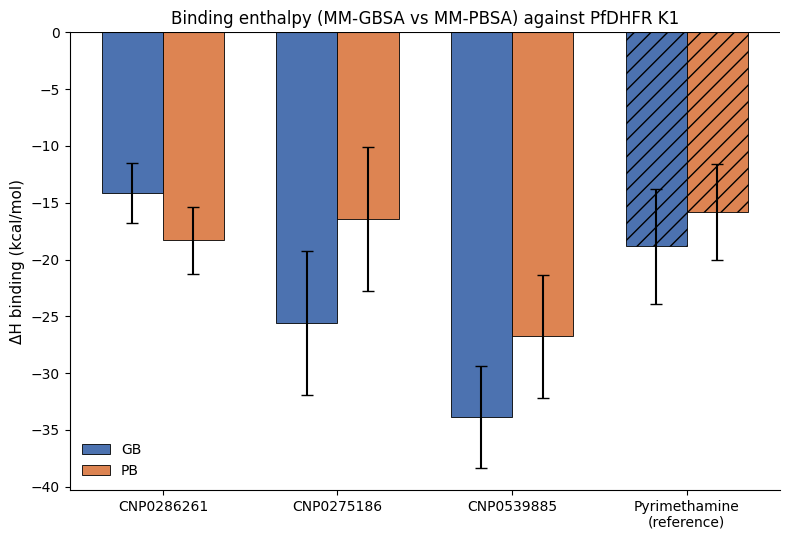

Saved to: /home/kenjo/mmpbsa_project/figures/fig_dH_comparison.png


In [8]:
# ── CELL 26: Build the ΔH (GB vs PB) comparison bar chart ──

import matplotlib.pyplot as plt
import numpy as np

# Reconstruct the ΔH values already extracted in Cell 17 (gb_delta_total, pb_delta_total)
# In case kernel state was lost, these are hardcoded from the confirmed table:
dh_data = {
    "CNP0286261_0": {"gb": -14.13, "gb_sem": 2.62, "pb": -18.32, "pb_sem": 2.97},
    "CNP0275186_1": {"gb": -25.58, "gb_sem": 6.31, "pb": -16.44, "pb_sem": 6.31},
    "CNP0539885_2": {"gb": -33.89, "gb_sem": 4.48, "pb": -26.74, "pb_sem": 5.41},
    "pyrimethamine": {"gb": -18.83, "gb_sem": 5.08, "pb": -15.83, "pb_sem": 4.23},
}

labels = list(dh_data.keys())
display_labels = ["CNP0286261", "CNP0275186", "CNP0539885", "Pyrimethamine\n(reference)"]
gb_vals = [dh_data[k]["gb"] for k in labels]
gb_sems = [dh_data[k]["gb_sem"] for k in labels]
pb_vals = [dh_data[k]["pb"] for k in labels]
pb_sems = [dh_data[k]["pb_sem"] for k in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5.5))

bars_gb = ax.bar(x - width/2, gb_vals, width, yerr=gb_sems, capsize=4,
                  label="GB", color="#4C72B0", edgecolor="black", linewidth=0.6)
bars_pb = ax.bar(x + width/2, pb_vals, width, yerr=pb_sems, capsize=4,
                  label="PB", color="#DD8452", edgecolor="black", linewidth=0.6)

# Highlight pyrimethamine reference with hatching
bars_gb[-1].set_hatch("//")
bars_pb[-1].set_hatch("//")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("ΔH binding (kcal/mol)", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(display_labels, fontsize=10)
ax.set_title("Binding enthalpy (MM-GBSA vs MM-PBSA) against PfDHFR K1", fontsize=12)
ax.legend(frameon=False, fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

output_path = PROJECT_ROOT / "figures" / "fig_dH_comparison.png"
output_path.parent.mkdir(exist_ok=True)
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {output_path}")

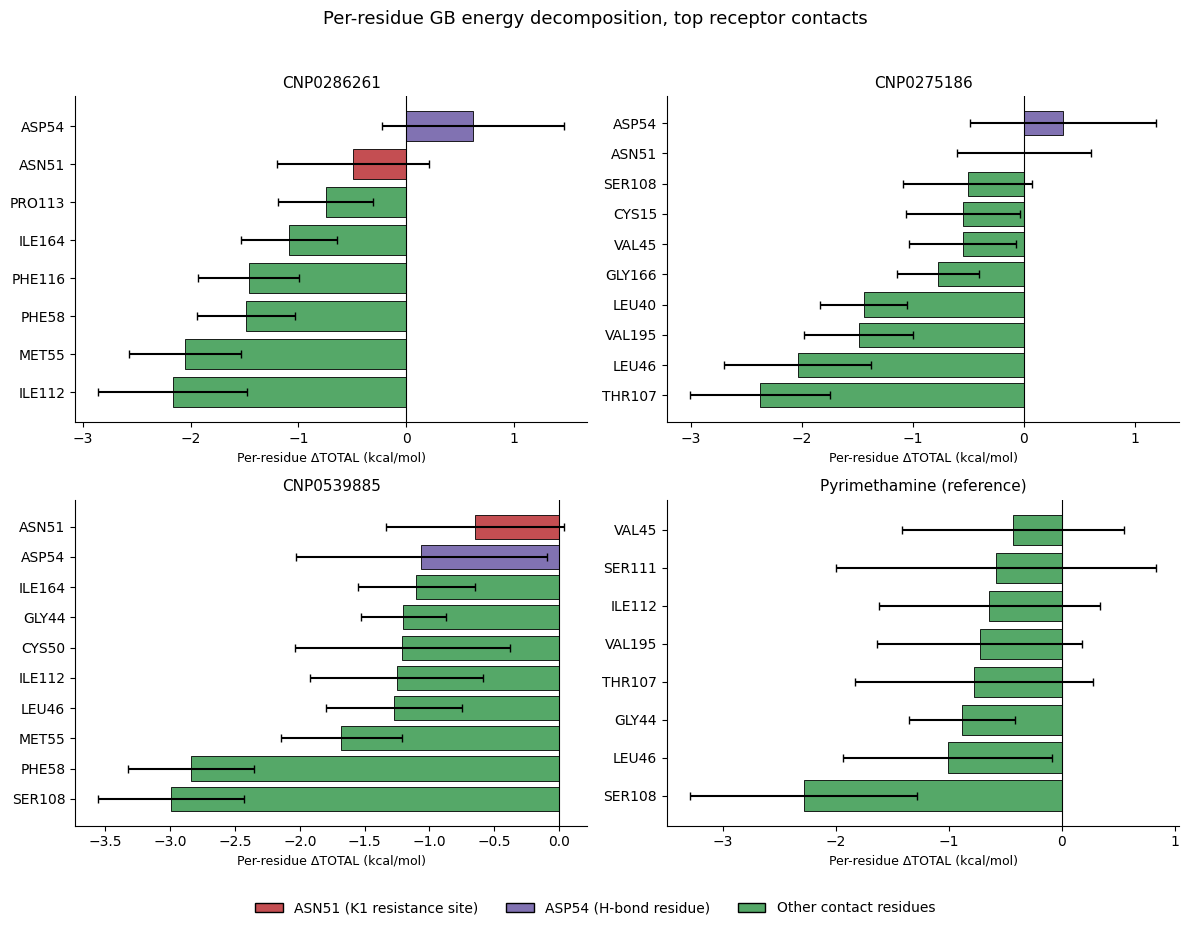

Saved to: /home/kenjo/mmpbsa_project/figures/fig_residue_decomposition.png


In [9]:
# ── CELL 27: Build the per-residue energy decomposition chart with ASN51/ASP54 highlighted ──

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False)
axes = axes.flatten()

compound_order = ["CNP0286261_0", "CNP0275186_1", "CNP0539885_2", "pyrimethamine"]
display_names = ["CNP0286261", "CNP0275186", "CNP0539885", "Pyrimethamine (reference)"]

for ax, name, disp in zip(axes, compound_order, display_names):
    df = decomp_data[name]
    receptor_only = df[~df["Residue"].str.startswith("L:")].copy()

    # Get top 8 by magnitude
    receptor_only["abs_total"] = receptor_only["TOTAL_Avg"].abs()
    top8 = receptor_only.sort_values("abs_total", ascending=False).head(8).copy()

    # Force-include ASN51 and ASP54 if not already in top 8
    for tag in [":51$", ":54$"]:
        match = receptor_only[receptor_only["Residue"].str.contains(tag, regex=True)]
        if not match.empty and match.index[0] not in top8.index:
            top8 = pd.concat([top8, match])

    top8 = top8.sort_values("TOTAL_Avg")  # ascending for horizontal bar order

    colors = []
    for res in top8["Residue"]:
        if ":51:" in res or res.endswith(":51"):
            colors.append("#C44E52")  # red: ASN51, resistance site
        elif ":54:" in res or res.endswith(":54"):
            colors.append("#8172B2")  # purple: ASP54, H-bond residue
        else:
            colors.append("#55A868")  # green: other contact residues

    clean_labels = [r.split(":")[2] + r.split(":")[3] for r in top8["Residue"]]

    ax.barh(clean_labels, top8["TOTAL_Avg"], xerr=top8["TOTAL_SEM"],
             color=colors, edgecolor="black", linewidth=0.6, capsize=3)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(disp, fontsize=11)
    ax.set_xlabel("Per-residue ΔTOTAL (kcal/mol)", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Shared legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#C44E52", edgecolor="black", label="ASN51 (K1 resistance site)"),
    Patch(facecolor="#8172B2", edgecolor="black", label="ASP54 (H-bond residue)"),
    Patch(facecolor="#55A868", edgecolor="black", label="Other contact residues"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, frameon=False, fontsize=10, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Per-residue GB energy decomposition, top receptor contacts", fontsize=13, y=1.00)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])

output_path = PROJECT_ROOT / "figures" / "fig_residue_decomposition.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {output_path}")

In [10]:
# ── CELL 28: Build the Figure 1 companion table ──

table_rows = []
for name in ["CNP0286261_0", "CNP0275186_1", "CNP0539885_2", "pyrimethamine"]:
    d = dh_data[name]
    table_rows.append({
        "Compound": name,
        "ΔH (GB), kcal/mol": f"{d['gb']:.2f} ± {d['gb_sem']:.2f}",
        "ΔH (PB), kcal/mol": f"{d['pb']:.2f} ± {d['pb_sem']:.2f}",
    })

# Merge in ΔG (IE-corrected) values from the earlier consolidated table
dg_data = {
    "CNP0286261_0": {"gb_dg": -1.40, "gb_dg_sem": 2.62, "pb_dg": -5.59, "pb_dg_sem": 2.97},
    "CNP0275186_1": {"gb_dg": -6.52, "gb_dg_sem": 6.31, "pb_dg": 2.61, "pb_dg_sem": 6.31},
    "CNP0539885_2": {"gb_dg": -18.90, "gb_dg_sem": 4.48, "pb_dg": -11.75, "pb_dg_sem": 5.41},
    "pyrimethamine": {"gb_dg": -1.84, "gb_dg_sem": 5.08, "pb_dg": 1.16, "pb_dg_sem": 4.23},
}

for row in table_rows:
    name = row["Compound"]
    d = dg_data[name]
    row["ΔG (GB, IE-corrected), kcal/mol"] = f"{d['gb_dg']:.2f} ± {d['gb_dg_sem']:.2f}"
    row["ΔG (PB, IE-corrected), kcal/mol"] = f"{d['pb_dg']:.2f} ± {d['pb_dg_sem']:.2f}"

table_df = pd.DataFrame(table_rows)
table_df["Compound"] = table_df["Compound"].replace({
    "CNP0286261_0": "CNP0286261",
    "CNP0275186_1": "CNP0275186",
    "CNP0539885_2": "CNP0539885",
    "pyrimethamine": "Pyrimethamine (reference)",
})

print(table_df.to_string(index=False))

table_csv_path = PROJECT_ROOT / "figures" / "table1_dH_dG_summary.csv"
table_df.to_csv(table_csv_path, index=False)
print(f"\nSaved to: {table_csv_path}")

                 Compound ΔH (GB), kcal/mol ΔH (PB), kcal/mol ΔG (GB, IE-corrected), kcal/mol ΔG (PB, IE-corrected), kcal/mol
               CNP0286261     -14.13 ± 2.62     -18.32 ± 2.97                    -1.40 ± 2.62                    -5.59 ± 2.97
               CNP0275186     -25.58 ± 6.31     -16.44 ± 6.31                    -6.52 ± 6.31                     2.61 ± 6.31
               CNP0539885     -33.89 ± 4.48     -26.74 ± 5.41                   -18.90 ± 4.48                   -11.75 ± 5.41
Pyrimethamine (reference)     -18.83 ± 5.08     -15.83 ± 4.23                    -1.84 ± 5.08                     1.16 ± 4.23

Saved to: /home/kenjo/mmpbsa_project/figures/table1_dH_dG_summary.csv
